## Incorporate responces from Chengyu, Nick and Michael
- Michael and Nick: average log2(RNA/DNA)
- make it nice from qualit_control_MPRAsnakeflow.ipynb
- check mannwhitneyu for scrambled and chengyu controls

#### Outline:
1. imports and loading of the data (merged_tsv + combine average log2 for the replicates)
2. Read the numbers for MK: add positive and negative 

In [10]:
import pandas as pd
import numpy as np

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf


In [11]:
# helpful functions
def combine_replicates(df_allreps, total_dna_counts, total_rna_counts):
    df_allreps = df_allreps.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )
    
    df_allreps = df_allreps.reset_index()
    df_out = df_allreps.iloc[:, 0:2]
    df_out.columns = ["condition", "name"]

    df_out["replicates"] = df_allreps.replicate["count"]

    scaling = 10**6

    df_out["dna_counts"] = df_allreps.dna_counts["sum"]
    df_out["rna_counts"] = df_allreps.rna_counts["sum"]


    df_out["dna_normalized"] = df_out["dna_counts"] / total_dna_counts * scaling
    df_out["rna_normalized"] = df_out["rna_counts"] / total_rna_counts * scaling

    df_out["ratio"] = df_out["rna_normalized"] / df_out["dna_normalized"]
    df_out["log2"] = np.log2(df_out.ratio)

    df_out["mean_dna_counts"] = df_allreps.dna_counts["mean"]
    df_out["mean_rna_counts"] = df_allreps.rna_counts["mean"]
    df_out["mean_dna_normalized"] = df_allreps.dna_normalized["mean"]
    df_out["mean_rna_normalized"] = df_allreps.rna_normalized["mean"]
    df_out["mean_ratio"] = df_allreps.ratio["mean"]
    df_out["mean_log2"] = df_allreps.log2["mean"]
    
    df_out["mean_n_obs_bc"] = df_allreps.n_obs_bc["mean"].apply(int)
    return df_out

In [12]:
merged_tsv_path = '/home/kisa/coding/80K_MPRA/design_data/NGN2_allreps_minThreshold_merged.tsv.gz'
merged_tsv = pd.read_csv(merged_tsv_path, sep='\t')
merged_tsv

# aggregate the replicate tsv 
total_dna_counts = merged_tsv[["dna_counts"]].sum().iloc[0]
total_rna_counts = merged_tsv[["rna_counts"]].sum().iloc[0]

merged_replicates_df = combine_replicates(merged_tsv, total_dna_counts, total_rna_counts)
merged_replicates_df


# add label
merged_replicates_df['label'] = merged_replicates_df['name'].apply(hf.get_label)

In [13]:
merged_replicates_df

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1069,2587,13.157426,13.750557,1.045080,0.063613,3.563333e+02,8.623333e+02,0.121140,0.126572,1.080802,0.111316,108,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1140,5188,14.031306,27.575528,1.965286,0.974739,3.800000e+02,1.729333e+03,0.137726,0.270879,2.040802,1.022238,101,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,638,1632,7.852608,8.674492,1.104664,0.143607,2.126667e+02,5.440000e+02,0.116224,0.128225,1.140693,0.189335,67,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,922,2260,11.348126,12.012470,1.058542,0.082079,3.073333e+02,7.533333e+02,0.124520,0.132123,1.099769,0.132576,90,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,595,1412,7.323357,7.505136,1.024822,0.035373,1.983333e+02,4.706667e+02,0.133440,0.136954,1.060619,0.084120,54,C_SLEA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68728,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,631,2799,7.766451,14.877391,1.915597,0.937794,2.103333e+02,9.330000e+02,0.102176,0.195736,1.986678,0.982698,75,cardiac_neuro_cava_random
68729,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,197,646,2.424708,3.433653,1.416110,0.501933,6.566667e+01,2.153333e+02,0.099126,0.140391,1.475498,0.558521,24,cardiac_neuro_cava_random
68730,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,216,334,2.658563,1.775294,0.667765,-0.582589,7.200000e+01,1.113333e+02,0.089462,0.059643,0.690325,-0.539574,29,cardiac_neuro_cava_random
68731,NGN2,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3,946,2013,11.643522,10.699603,0.918932,-0.121970,3.153333e+02,6.710000e+02,0.109184,0.100268,0.952268,-0.072310,106,cardiac_neuro_cava_random


In [ ]:
n_bcs = 70
group_names = ['C_negative_neuron_MK', 'C_positive_neuron_MK', 'C_positive_neuron_NP', 'C_negative_neuron_NP']

for group in group_names:

raw_merged = merged_allreps_df[merged_allreps_df['label'] == group]


plot_correlation(C_negative_neuron_MK, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', f'C_negative_neuron_MK (barcodes {n_bcs})', f'/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/C_negative_neuron_MK_{n_bcs}bc_correlation.png')
plot_histogram(C_negative_neuron_MK, 'C_negative_neuron_MK', n_bcs, 30, f'/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/C_negative_neuron_MK_{n_bcs}bcs_log2ratio.png')

# C_negative_neuron_NP
# C_negative_neuron_NP = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_negative_neuron_NP']
C_negative_neuron_NP = merged_allreps_df[merged_allreps_df['label'] == 'C_negative_neuron_NP']
C_negative_neuron_NP['given_value'] = C_negative_neuron_NP['name'].apply(get_ratio_with_underscore)

# filtering
C_negative_neuron_NP_filtered = C_negative_neuron_NP.loc[C_negative_neuron_NP['mean_n_obs_bc'] > n_bcs]

plot_correlation(C_negative_neuron_NP_filtered, 'given_value', 'mean_ratio', 'given_value', 'mean_ratio', f'C_negative_neuron_NP (barcodes {n_bcs})', f'/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/C_negative_neuron_NP_{n_bcs}bc_correlation.png')
plot_histogram(C_negative_neuron_NP_filtered, 'C_negative_neuron_NP', n_bcs, 30, f'/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/C_negative_neuron_NP_{n_bcs}bcs_log2ratio.png')
# C_positive_neuron_MK
# C_positive_neuron_MK = allreps_minthreshold_df[allreps_minthreshold_df['label'] == 'C_positive_neuron_MK']
C_positive_neuron_MK = merged_allreps_df[merged_allreps_df['label'] == 'C_positive_neuron_MK']
C_positive_neuron_MK['given_value'] = C_positive_neuron_MK['name'].apply(get_ratio_with_underscore)


#### Check Chengyu controls: 
- The correlation is still bad like the other neuron controls which is expected according to Nick and Michael
- Nick would like to see the results of the MK after 
- Plan:
  1. load chengy controls and scrambled controls from MK 
  2. compare their mean log2 distribution with mannwhitneyu

In [66]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

In [4]:
# scripts to check chengyu controls
def combine_replicates(df_allreps, total_dna_counts, total_rna_counts):
    """Taken from the MPRAsnakeflow script"""
    df_allreps = df_allreps.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )
    
    df_allreps = df_allreps.reset_index()
    df_out = df_allreps.iloc[:, 0:2]
    df_out.columns = ["condition", "name"]

    df_out["replicates"] = df_allreps.replicate["count"]

    scaling = 10**6

    df_out["dna_counts"] = df_allreps.dna_counts["sum"]
    df_out["rna_counts"] = df_allreps.rna_counts["sum"]


    df_out["dna_normalized"] = df_out["dna_counts"] / total_dna_counts * scaling
    df_out["rna_normalized"] = df_out["rna_counts"] / total_rna_counts * scaling

    df_out["ratio"] = df_out["rna_normalized"] / df_out["dna_normalized"]
    df_out["log2"] = np.log2(df_out.ratio)

    df_out["mean_dna_counts"] = df_allreps.dna_counts["mean"]
    df_out["mean_rna_counts"] = df_allreps.rna_counts["mean"]
    df_out["mean_dna_normalized"] = df_allreps.dna_normalized["mean"]
    df_out["mean_rna_normalized"] = df_allreps.rna_normalized["mean"]
    df_out["mean_ratio"] = df_allreps.ratio["mean"]
    df_out["mean_log2"] = df_allreps.log2["mean"]
    
    df_out["mean_n_obs_bc"] = df_allreps.n_obs_bc["mean"].apply(int)
    return df_out

In [11]:
# load mprasnakeflow data and compute mean replicates (barcode threshold = 10)
merged_tsv_path = '/home/kisa/coding/80K_MPRA/design_data/NGN2_allreps_minThreshold_merged.tsv.gz'
merged_tsv = pd.read_csv(merged_tsv_path, sep='\t')
# aggregate the replicate tsv 
total_dna_counts = merged_tsv[["dna_counts"]].sum().iloc[0]
total_rna_counts = merged_tsv[["rna_counts"]].sum().iloc[0]

merged_replicates_df = combine_replicates(merged_tsv, total_dna_counts, total_rna_counts)
merged_replicates_df
# filtered_merged_replicates_df = combine_replicates(filtered_merged, total_dna_counts, total_rna_counts)
# filtered_merged_replicates_df


# # add label
merged_replicates_df['label'] = merged_replicates_df['name'].apply(hf.get_label)
# filtered_merged_replicates_df['label'] = filtered_merged_replicates_df['name'].apply(hf.get_label)

Identified the scrambled negative sequences from Michael Kosicki (in design 500 and in our data 473)

In [16]:
scrambled_negative_MK = merged_replicates_df.loc[merged_replicates_df['name'].str.endswith('scramble_negative')]
scrambled_negative_MK

scrambled_negative_MK_mean_log2 = scrambled_negative_MK['mean_log2'].to_list()

In [18]:
chengyu_neuro_positive_controls = merged_replicates_df.loc[merged_replicates_df['label'] == 'C_positive_neuron_CD']
chengyu_neuro_positive_controls.shape[0] # 51
chengyu_neuron_pos_mean_log2 = chengyu_neuro_positive_controls['mean_log2'].to_list()


In [22]:
# use mannwhitneyu for mean_log2 differences in these two groups
res = mannwhitneyu(chengyu_neuron_pos_mean_log2, scrambled_negative_MK_mean_log2, alternative="greater", method='asymptotic')
# res = mannwhitneyu(chengyu_neuron_pos_mean_log2, scrambled_negative_MK_mean_log2, method='asymptotic')
print(res)

MannwhitneyuResult(statistic=20904.0, pvalue=3.753749341491822e-18)


Use the same method for the statistical significants computation of neuron controls
- with alternative: => all are significantly different from scrambled
    - C_negative_neuron_NP
    - MannwhitneyuResult(statistic=1325.0, pvalue=3.3788369344906636e-57)
    - C_positive_neuron_NP
    - MannwhitneyuResult(statistic=29679.0, pvalue=8.393626194373701e-38)
    - C_positive_neuron_MK
    - MannwhitneyuResult(statistic=42527.0, pvalue=2.5283755473556964e-46)
    - C_negative_neuron_MK
    - MannwhitneyuResult(statistic=18817.0, pvalue=7.246778268182224e-27)
    - C_positive_neuron_CD
    - MannwhitneyuResult(statistic=20904.0, pvalue=3.753749341491822e-18)

In [25]:
neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK', 'C_positive_neuron_CD']
for control in neuro_controls:
    print(control)
    neuro_control_df = merged_replicates_df.loc[merged_replicates_df['label'] == control]
    neuron_mean_log2 = neuro_control_df['mean_log2'].to_list()
    alternative = 'less'
    if "positive" in control:
        alternative = 'greater'
    res = mannwhitneyu(neuron_mean_log2, scrambled_negative_MK_mean_log2, alternative=alternative, method='asymptotic')
    print(res)


C_negative_neuron_NP
MannwhitneyuResult(statistic=1325.0, pvalue=3.3788369344906636e-57)
C_positive_neuron_NP
MannwhitneyuResult(statistic=29679.0, pvalue=8.393626194373701e-38)
C_positive_neuron_MK
MannwhitneyuResult(statistic=42527.0, pvalue=2.5283755473556964e-46)
C_negative_neuron_MK
MannwhitneyuResult(statistic=18817.0, pvalue=7.246778268182224e-27)
C_positive_neuron_CD
MannwhitneyuResult(statistic=20904.0, pvalue=3.753749341491822e-18)


Correlation of all neuron controls pos and negative
- functions: get ratio from the header

In [63]:
def get_ratio_with_underscore(header):
    """
    C_negative_neuron_MK:tile_14444_chr15_67066278_67066547_reference__1.1385203581298 => -1.13852
    C_negative_neuron_NP:GW18_PFC_ABC_chr15_89400286_89400556_0.830617698776558 => 0.8306176
    C_positive_heart_MK:tile_19089_chr18_25285984_25286253_reference_0.325720370916156' => 0.3257
    C_negative_heart_MK:tile_28156_chr3_50600413_50600682_reference__0.107234975260759 => -0.10723
    """
    if '_MK' in header and "__" in header:
        return float(header.split('_')[-1]) * -1
    return float(header.split('_')[-1])


def plot_correlation(df, column1, column2, color, name1, name2, title, save_path=""):
    """plot correlation between two columns"""
    # Calculate Pearson correlation coefficient
    pearson_corr = df[column1].corr(df[column2])

    # Plot correlation using Matplotlib's scatter plot with label as color
    sns.scatterplot(data=df, x=column1, y=column2, hue=color)
    plt.xlabel(name1)
    plt.ylabel(name2)
    plt.title(f'{title} \nPearson Correlation: {pearson_corr:.2f} (#sequences: {df.shape[0]})')
    plt.legend(loc="upper left")
    if save_path != "":
        if os.path.isdir('/'.join(save_path.split("/")[:-1])):
            plt.savefig(save_path, transparent=False)
    plt.show()

In [44]:
neuro_controls_MK_NP = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK']

neuro_controls_df = merged_replicates_df.loc[merged_replicates_df['label'].isin(neuro_controls_MK_NP)]
neuro_controls_df['given_mean_log2_ratio'] = neuro_controls_df['name'].apply(get_ratio_with_underscore)
neuro_controls_df # 447 

/tmp/ipykernel_2429/2836449549.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuro_controls_df['given_mean_log2_ratio'] = neuro_controls_df['name'].apply(get_ratio_with_underscore)


,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,label,given_mean_log2_ratio
350,NGN2,C_negative_neuron_MK:rdhs_105594_chr11_1907180...,3,266,260,3.273971,1.381966,0.422107,-1.244320,88.666667,86.666667,0.079959,0.033520,0.434939,-1.208581,41,C_negative_neuron_MK,-0.314590
351,NGN2,C_negative_neuron_MK:rdhs_220991_chr14_1035423...,3,347,697,4.270932,3.704731,0.867429,-0.205182,115.666667,232.333333,0.138280,0.119883,0.895906,-0.159566,30,C_negative_neuron_MK,-0.273025
352,NGN2,C_negative_neuron_MK:rdhs_335331_chr2_8642406_...,3,420,569,5.169428,3.024378,0.585051,-0.773366,140.000000,189.666667,0.087331,0.051213,0.606586,-0.725522,59,C_negative_neuron_MK,-0.280436
353,NGN2,C_negative_neuron_MK:rdhs_350036_chr2_60214636...,3,824,2024,10.141926,10.758070,1.060752,0.085088,274.666667,674.666667,0.124151,0.131886,1.098243,0.134922,81,C_negative_neuron_MK,-0.281429
354,NGN2,C_negative_neuron_MK:rdhs_350036_chr2_60214636...,3,499,1330,6.141773,7.069285,1.151017,0.202909,166.333333,443.333333,0.134129,0.153954,1.186019,0.245732,45,C_negative_neuron_MK,-0.366970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572,NGN2,C_positive_neuron_NP:NGN2_iPSC_ABC_chrX_959969...,3,787,7935,9.686524,42.176526,4.354145,2.122389,262.333333,2645.000000,0.141266,0.615385,4.503967,2.162483,68,C_positive_neuron_NP,5.170770
1573,NGN2,C_positive_neuron_NP:NGN2_iPSC_ABC_chrX_986523...,3,1889,16526,23.250120,87.839857,3.778039,1.917638,629.666667,5508.666667,0.107551,0.404947,3.889746,1.954803,215,C_positive_neuron_NP,5.210336
1574,NGN2,C_positive_neuron_NP:NGN2_iPSC_ABC_chrX_986524...,3,850,8380,10.461938,44.541813,4.257511,2.090010,283.333333,2793.333333,0.128655,0.544102,4.378474,2.117928,81,C_positive_neuron_NP,5.381644
1575,NGN2,C_positive_neuron_NP:NGN2_iPSC_ABC_chrX_986525...,3,111,1336,1.366206,7.101177,5.197735,2.377883,37.000000,445.333333,0.099161,0.521226,5.493366,2.434726,13,C_positive_neuron_NP,5.265086


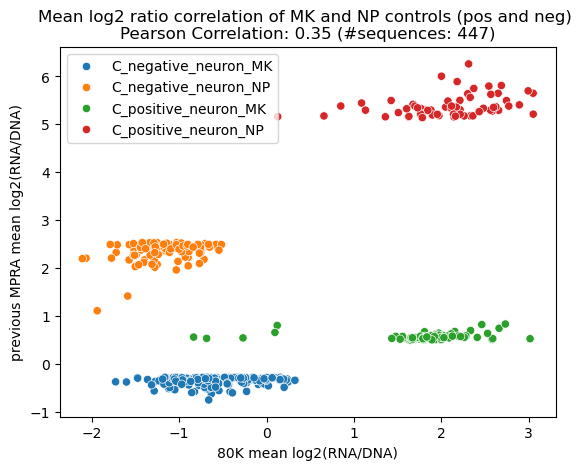

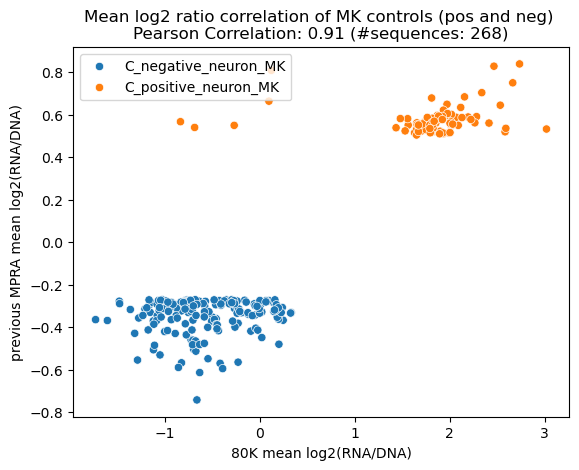

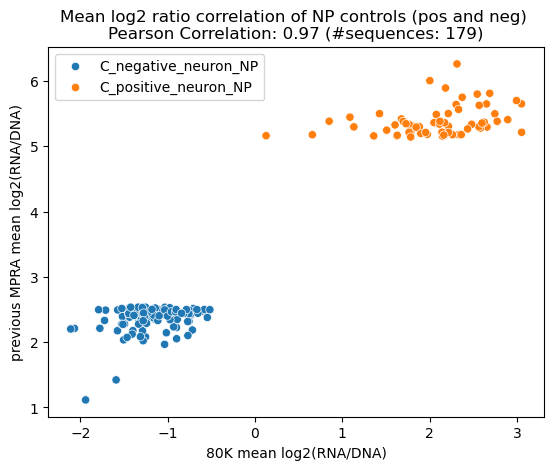

In [69]:
# split 
neuro_controls_MK = ['C_positive_neuron_MK',  'C_negative_neuron_MK']
neuro_controls_NP = ['C_negative_neuron_NP', 'C_positive_neuron_NP']
neuro_control_MK_df = neuro_controls_df.loc[neuro_controls_df['label'].isin(neuro_controls_MK)]
neuro_control_NP_df = neuro_controls_df.loc[neuro_controls_df['label'].isin(neuro_controls_NP)]

plot_correlation(neuro_controls_df, 'mean_log2', 'given_mean_log2_ratio', 'label', '80K mean log2(RNA/DNA)', 'previous MPRA mean log2(RNA/DNA)', 'Mean log2 ratio correlation of MK and NP controls (pos and neg)', '/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/NP_MK_pos_neg_combined_correlation.png')
plot_correlation(neuro_control_MK_df, 'mean_log2', 'given_mean_log2_ratio', 'label', '80K mean log2(RNA/DNA)', 'previous MPRA mean log2(RNA/DNA)', 'Mean log2 ratio correlation of MK controls (pos and neg)', '/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/MK_pos_neg_combined_correlation.png')
plot_correlation(neuro_control_NP_df, 'mean_log2', 'given_mean_log2_ratio', 'label', '80K mean log2(RNA/DNA)', 'previous MPRA mean log2(RNA/DNA)', 'Mean log2 ratio correlation of NP controls (pos and neg)', '/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/results/neuro_controls/not_transparent/NP_pos_neg_combined_correlation.png')


##### Notes from the meeting presenting these plots
- Do not show the correlation: stick with the log2(RNA/DNA) ratio histogram and tell them that the between experiments correlation is not high
- Add violin plot with the significants added 